# Telco Customer Churn Analysis

## Business Problem
Every company loses customers. The objective of this project is to identify customer behaviors that predict churn and uncover patterns that can support customer retention strategies.

## Focus Areas
- Customer tenure
- Contract type
- Monthly charges
- Service usage

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
The dataset contains customer demographics, account information, service subscriptions, and churn behavior.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/lorettahayford/telco-customer-churn/Telco-Customer-Churn.csv')




In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Cleaning
Data cleaning, this ensures the dataset is accurate, complete, and ready for analysis.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Handling Missing Values
The TotalCharges column may contains blank values that must be converted and cleaned

In [6]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce')

In [7]:
df = df.dropna()

# Exploratory Data Analysis (EDA)
My EDA helps identify customer behavior trends, churn patterns, and relationships between variables.

In [8]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

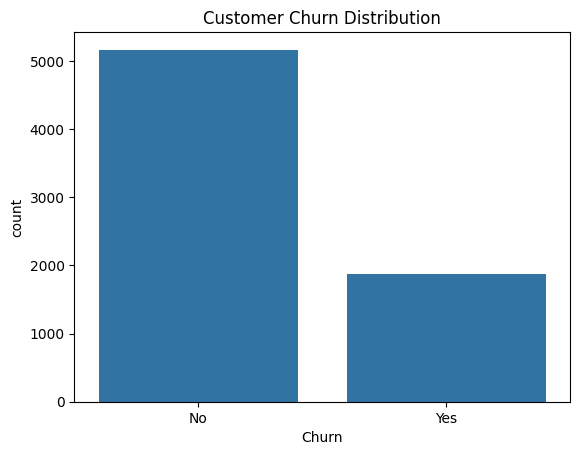

In [9]:
sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')

plt.show()

# Insight
A significant percentage of customers have churned, indicating a customer retention challenge.

# Customer Tenure Analysis
This analysis explores whether newer customers are more likely to churn.

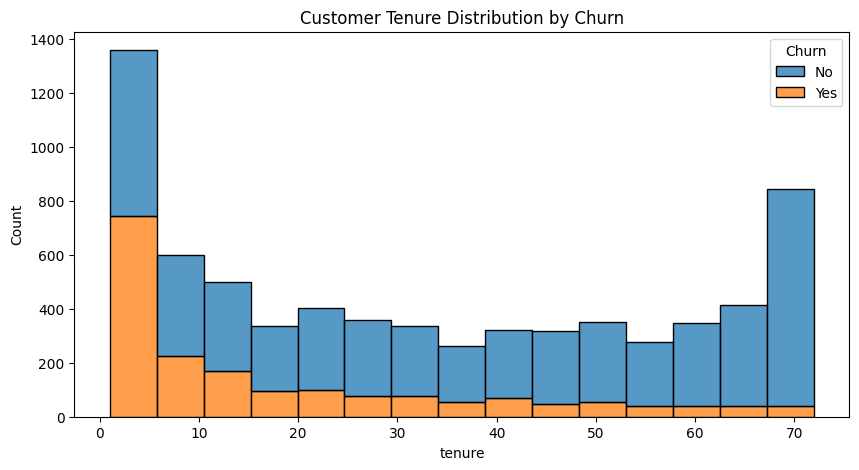

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    multiple='stack'
)

plt.title('Customer Tenure Distribution by Churn')

plt.show()

# Insight
Customers with shorter tenure show higher churn behavior, suggesting early retention is critical.

In [11]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn']
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


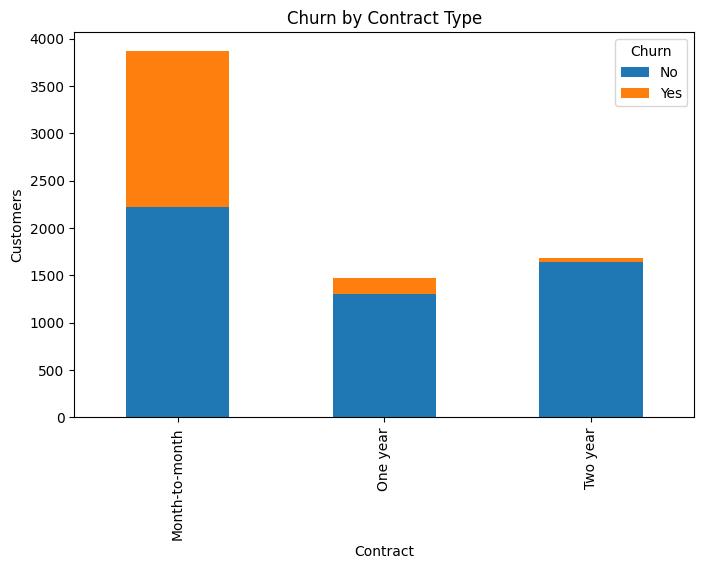

In [12]:
contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Churn by Contract Type')

plt.ylabel('Customers')

plt.show()

# Insight
Month-to-month customers exhibit the highest churn levels due to lower long-term commitment.

# Monthly Charges Analysis
This analysis explores whether higher charges increase churn risk.

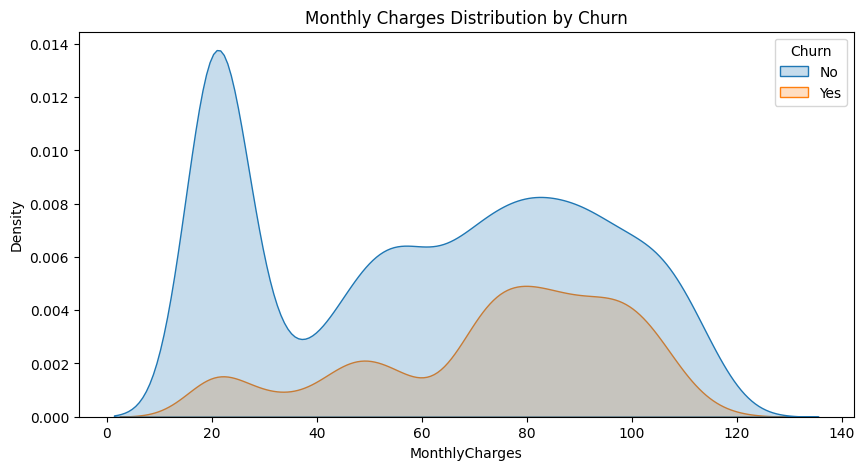

In [13]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    fill=True
)

plt.title('Monthly Charges Distribution by Churn')

plt.show()

# Insight
Customers with higher monthly charges demonstrate elevated churn behavior, suggesting pricing sensitivity.

# Service Usage Analysis
This analysis evaluates whether support-related services improve customer retention.

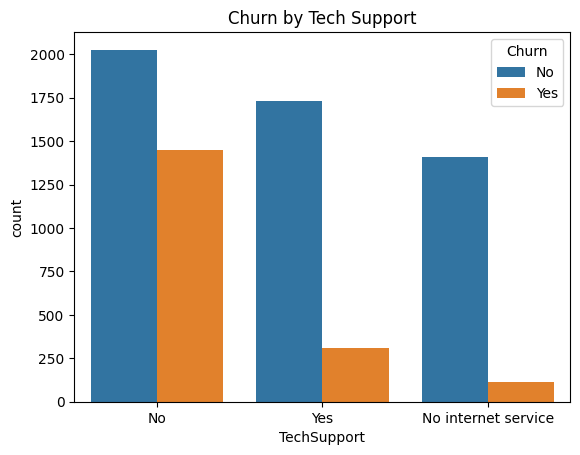

In [14]:
sns.countplot(
    x='TechSupport',
    hue='Churn',
    data=df
)

plt.title('Churn by Tech Support')

plt.show()

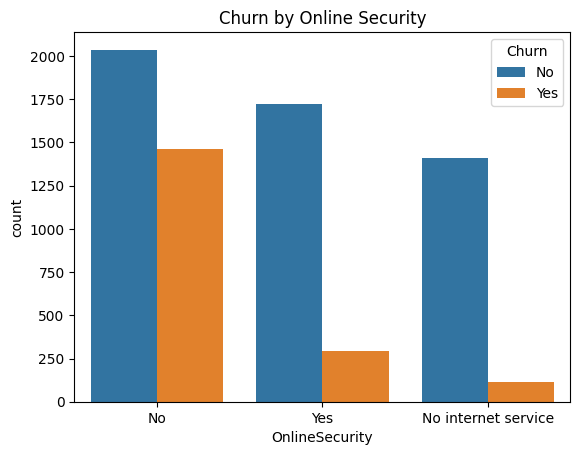

In [15]:
sns.countplot(
    x='OnlineSecurity',
    hue='Churn',
    data=df
)

plt.title('Churn by Online Security')

plt.show()

# Insight
Customers without support-related services churn more frequently, indicating service engagement improves retention.

# Customer Behavior Trends
This section identifies patterns associated with high-risk customers.

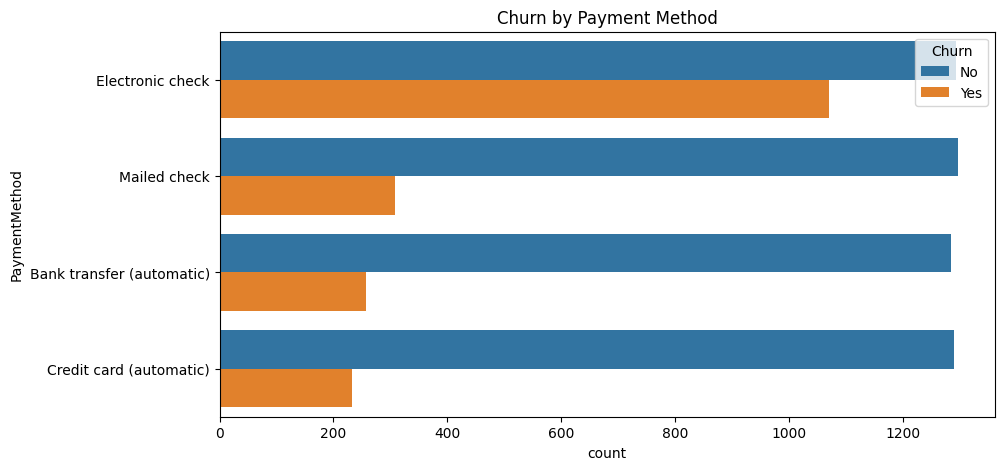

In [16]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='PaymentMethod',
    hue='Churn',
    data=df
)

plt.title('Churn by Payment Method')

plt.show()

# Insight
Electronic check users show higher churn behavior compared to customers using automatic payment methods.

# Early Churn Indicators
This analysis identifies characteristics commonly associated with customers who churn early.

In [17]:
numeric_df = df[
    ['tenure',
     'MonthlyCharges',
     'TotalCharges']
]

numeric_df.corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


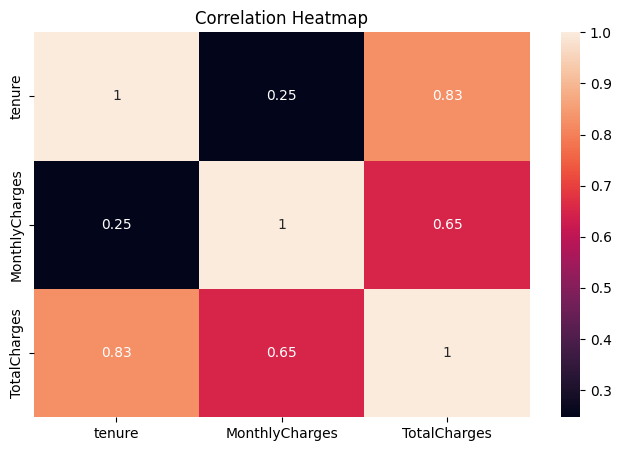

In [18]:
plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title('Correlation Heatmap')

plt.show()

# Final Business Insights

## Key Findings
- Month-to-month contracts are the strongest churn driver.
- Customers within their first year are highest risk.
- Higher monthly charges increase churn likelihood.
- Customers without support services churn more frequently.
- Long-term contracts and service engagement improve retention.

## Business Recommendation
The company should strengthen onboarding, incentivize long-term contracts, and increase customer engagement through support-related services.